In [23]:
import tensorflow as tf
import numpy as np 
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions
from tensorflow.keras.applications.xception import Xception

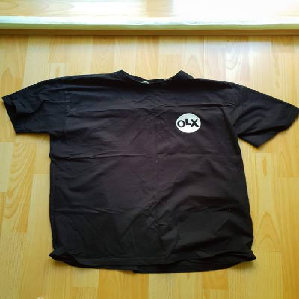

In [4]:
img_path = './train/t-shirt/'
img_name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

img = load_img(img_path+img_name,target_size=(299,299))
img

In [11]:
x = np.array(img)

In [12]:
x.shape

(299, 299, 3)

In [16]:
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [18]:
X = preprocess_input(X)

In [20]:
model = Xception(weights='imagenet',input_shape=(299,299,3))

I0000 00:00:1741747146.995320     469 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [22]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


In [24]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n03595614', 'jersey', np.float32(0.68250936)),
  ('n02916936', 'bulletproof_vest', np.float32(0.037945513)),
  ('n04370456', 'sweatshirt', np.float32(0.03434995)),
  ('n03710637', 'maillot', np.float32(0.011343054)),
  ('n04525038', 'velvet', np.float32(0.0018461886))]]

## Transfer Learning

Pretrained model - Imagenet

- Read with ImageGenerator
- Train Xception

- Work with the vector representation from Imagenet, but not the dense layers
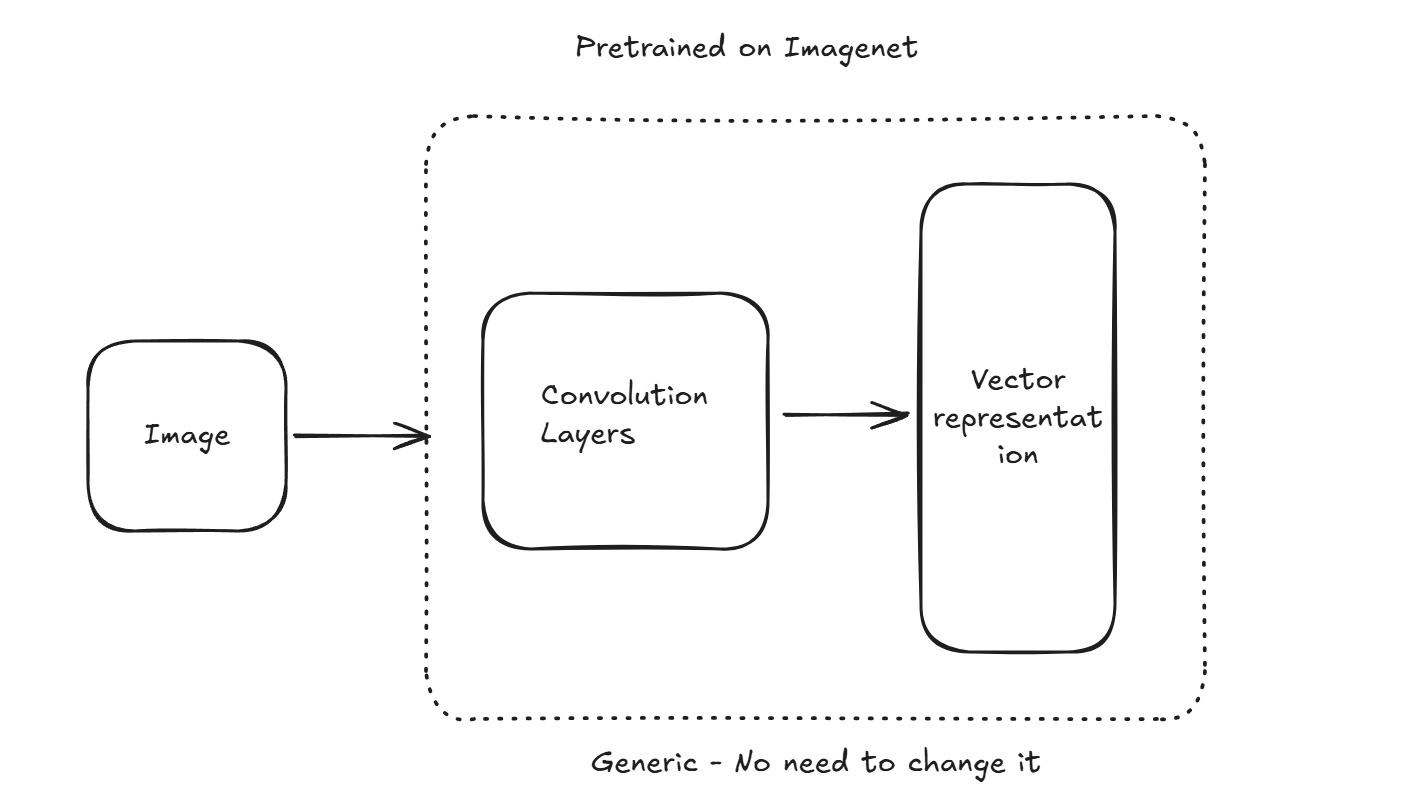

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input

In [43]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [33]:
train_ds = train_gen.flow_from_directory(
    './train/',target_size=(150,150),batch_size=32
)

Found 3068 images belonging to 10 classes.


In [34]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [36]:
X,y = next(train_ds)

In [39]:
# X is representation of the batch of images
X.shape

(32, 150, 150, 3)

In [42]:
# y represents our target variable
"""
There are 10 classes
- When a value of 1 appears, then the target variable matches the class of the item
y[0] has 1 at possition 7, which corresponds with shorts

--> This is onehot encoding 
"""
y[:4]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], dtype=float32)

In [45]:
# Validation dataset
val_ds = val_gen.flow_from_directory(
    './validation/',target_size=(150,150),batch_size=32,shuffle=False
)

Found 341 images belonging to 10 classes.


### Train model
We train a custom model based off of a base model (Xception)
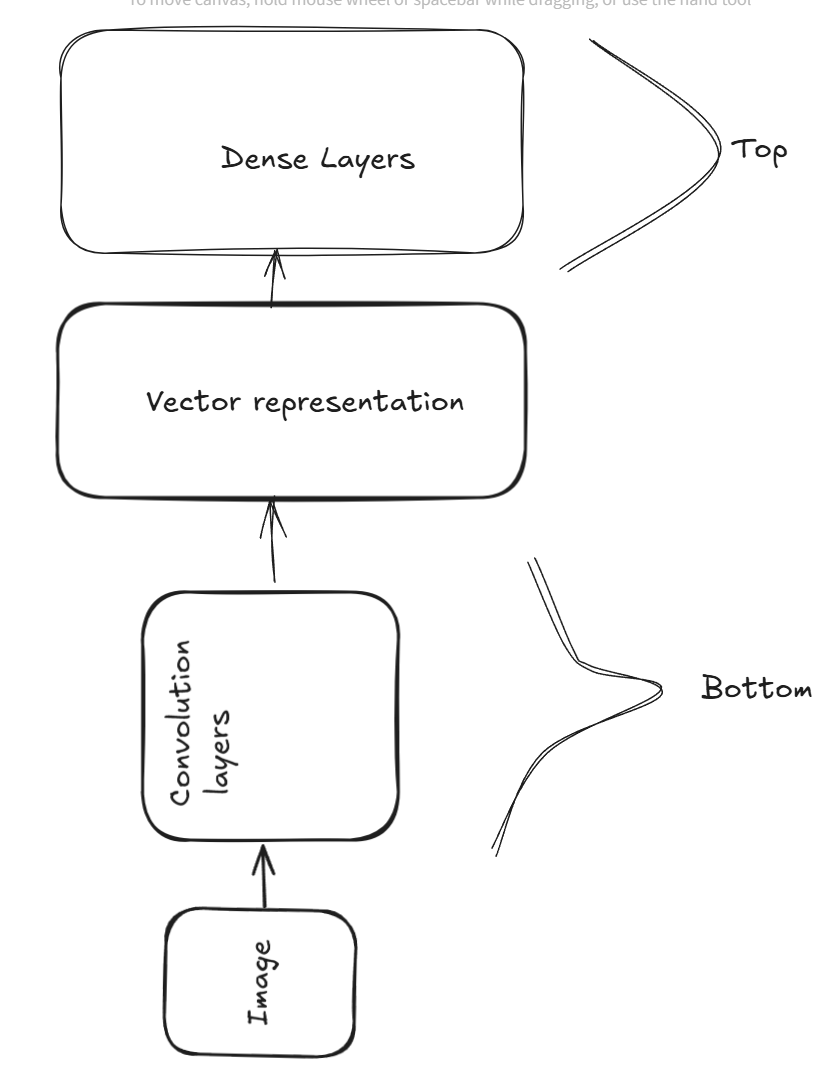

In [47]:
"""
We donot include the dense layers, hence include top false
Trainable is false because we do not want to train the convolution layers
"""

base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)
base_model.trainable = False

In [48]:
from tensorflow import keras

In [50]:
"""
Inputs are manipulated by base model to form base

Inputs = Batch of input Images

Outputs = Base, which is the Input manipulated by the Base Model

"""

inputs = keras.Input(shape=(150,150,3))
base = base_model(inputs)

outputs = base

model = keras.Model(inputs,outputs)